# Answer the question
1. “Dựa vào các chỉ số on-chain đặc biệt là miner revenue và fee, ta có thể dự đoán giá Bitcoin tăng hay giảm vào ngày hôm sau không?” 
2. “Dựa trên các đặc tính cấu trúc mạng lưới (như hash_rate, difficulty, active_addresses và tx_count), mạng Bitcoin có thể được phân thành các trạng thái thị trường đặc trưng nào? Các cụm này có phản ánh đúng các chu kỳ vĩ mô như Tích lũy (Accumulation), Hưng phấn (Bull-run), hay Khủng hoảng (Capitulation) không?”



## 1. First question

### 1.1 Libs and data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Thư viện Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler



In [22]:
df = pd.read_csv('../data/preprocessed/btc_onchain_daily_preprocessed.csv', parse_dates=['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4143 entries, 2015-01-01 to 2026-05-05
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   price_usd                         4143 non-null   int64
 1   active_addresses                  4143 non-null   int64
 2   tx_count                          4143 non-null   int64
 3   hash_rate                         4143 non-null   int64
 4   supply_current                    4143 non-null   int64
 5   fee_usd                           4143 non-null   int64
 6   difficulty                        4143 non-null   int64
 7   miner_revenue_usd                 4143 non-null   int64
 8   estimated_transaction_volume_usd  4143 non-null   int64
dtypes: int64(9)
memory usage: 323.7 KB


### 1.2 Feature Engineering & Label

In [ ]:
# compute log return for all cols
log_df = np.log(df / df.shift(1))

# create label Y=1 if tomorrow > today (tomorrow log return > 0)
# shift(-1): get tomorrow value
log_df['Target_Next_Day'] = (log_df['price_usd'].shift(-1) > 0).astype(int)

# create feature (lag value, 2)
features = ['price_usd', 'miner_revenue_usd', 'fee_usd', 'tx_count', 'hash_rate']
for col in features:
    log_df[f'{col}_lag1'] = log_df[col].shift(1)
    log_df[f'{col}_lag2'] = log_df[col].shift(2)
    log_df[f'{col}_lag3'] = log_df[col].shift(3)
    
    log_df[f'{col}_MA7'] = log_df[col].shift(1).rolling(window=7).mean()
    

# delete rows which have NaN value
log_df.dropna(inplace=True)

# scaling
X_cols = [col for col in log_df.columns if 'lag' in col or 'MA' in col or 'STD' in col]
X = log_df[X_cols]
y = log_df['Target_Next_Day']


### 1.3 Split train/test

In [24]:
split_idx = int(len(log_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_cols, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_cols, index=X_test.index)

### 1.4 Training

In [25]:
LEARNING_RATE = 0.05
RANDOM_STATE = 9527
N_ESTIMATORS = 111

In [26]:
models = {
    "XGBoost": XGBClassifier(n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))
    print("\n")

--- XGBoost ---
Accuracy: 51.15%
              precision    recall  f1-score   support

           0       0.50      0.46      0.48       404
           1       0.52      0.56      0.54       423

    accuracy                           0.51       827
   macro avg       0.51      0.51      0.51       827
weighted avg       0.51      0.51      0.51       827



--- Random Forest ---
Accuracy: 49.58%
              precision    recall  f1-score   support

           0       0.48      0.45      0.46       404
           1       0.51      0.54      0.52       423

    accuracy                           0.50       827
   macro avg       0.49      0.49      0.49       827
weighted avg       0.49      0.50      0.49       827



--- Logistic Regression ---
Accuracy: 49.70%
              precision    recall  f1-score   support

           0       0.47      0.25      0.32       404
           1       0.51      0.74      0.60       423

    accuracy                           0.50       827
   macr

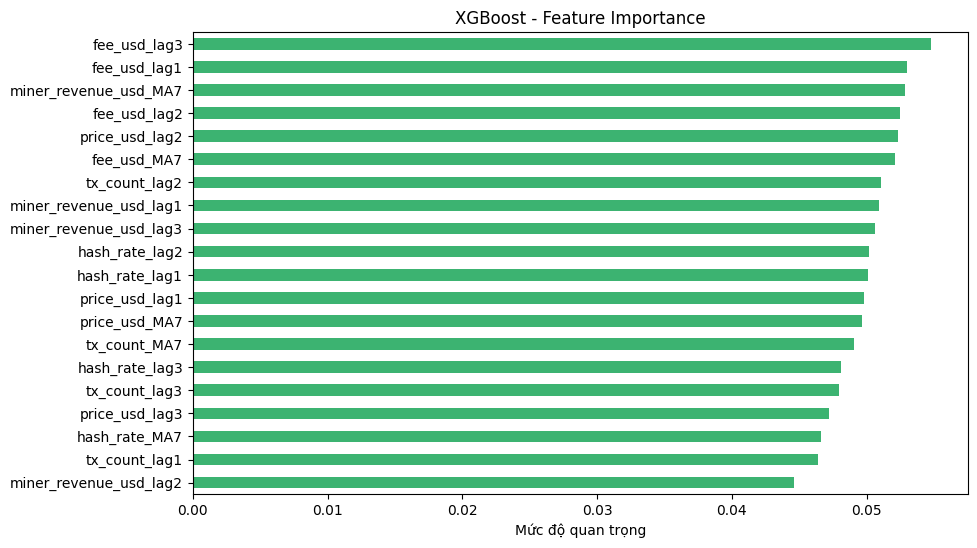

In [27]:
# get feature importance from XGBoost
xgb_model = models["XGBoost"]
importances = xgb_model.feature_importances_


feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='mediumseagreen')
plt.title("XGBoost - Feature Importance")
plt.xlabel("Mức độ quan trọng")
plt.show()